In [1]:
import numpy as np
import os
import pickle
import glob

from obspy import read, UTCDateTime

from matplotlib import dates as mdates
import matplotlib.pyplot as plt
plt.rcParams["date.converter"] = "concise"

from scatseisnet import ScatteringNetwork

In [2]:
network = pickle.load(open("/fp/projects01/ec332/data/Scattering_networks/scattering_network.pickle", "rb"))

In [3]:
# Load data from file
with np.load("/fp/homes01/u01/ec-karinal/New_bubbles/seisscatt_test/Scattering_networksscattering_coefficients_day1.npz", allow_pickle=True) as data:
    order_1 = data["order_1"]
    order_2 = data["order_2"]
    times = data["times"]

# Reshape and stack scattering coefficients of all orders
order_1rs = order_1.reshape(order_1.shape[0], -1)
order_2rs = order_2.reshape(order_2.shape[0], -1)
scattering_coefficients = np.hstack((order_1rs, order_2rs))

# transform into log
scattering_coefficients = np.log10(scattering_coefficients)

# print info about shape
n_times, n_coeff = scattering_coefficients.shape
print("Collected {} samples of {} dimensions each.".format(n_times, n_coeff))

print(scattering_coefficients)

Collected 24297 samples of 672 dimensions each.
[[ -0.8766804    0.26575376   1.29248398 ... -10.95996856  -5.67532855
   -3.39099978]
 [ -0.80715348   0.34405461   1.36328416 ... -11.75361948  -8.16326393
   -4.40685907]
 [ -0.6733474    0.38656626   1.36970195 ... -11.66223897  -7.00110506
   -3.97698198]
 ...
 [ -1.61470612  -0.33132669   0.72731208 ... -11.6541215   -5.81229374
   -3.30508416]
 [ -1.60727952  -0.34221992   0.71489829 ... -12.00616069  -8.17755948
   -4.1763482 ]
 [ -1.60238953  -0.33240152   0.71644142 ... -11.55703253  -5.51324052
   -3.30957091]]


In [4]:
times

array([datetime.datetime(2019, 5, 1, 4, 30, 17, 998000, tzinfo=datetime.timezone.utc),
       datetime.datetime(2019, 5, 1, 4, 30, 27, 998000, tzinfo=datetime.timezone.utc),
       datetime.datetime(2019, 5, 1, 4, 30, 37, 998000, tzinfo=datetime.timezone.utc),
       ...,
       datetime.datetime(2019, 5, 3, 23, 59, 17, 998000, tzinfo=datetime.timezone.utc),
       datetime.datetime(2019, 5, 3, 23, 59, 27, 998000, tzinfo=datetime.timezone.utc),
       datetime.datetime(2019, 5, 3, 23, 59, 37, 998000, tzinfo=datetime.timezone.utc)],
      dtype=object)

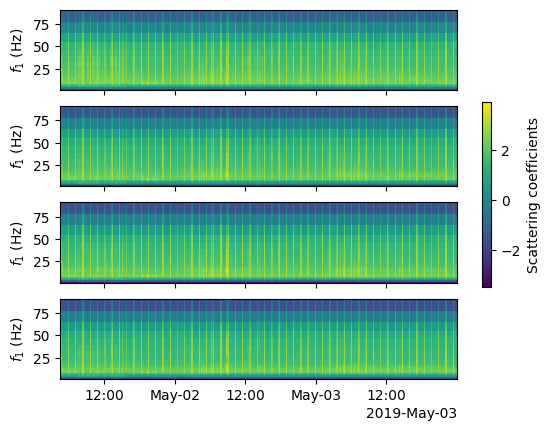

In [5]:
channels = ['A00.03','A00.04','A00.05','A00.06']
#channels = ['B00.01', 'B00.02','B00.03','B00.04','B00.05','B00.06']

f_1 = network.banks[0].centers
vmin = order_1.min()
vmax = order_1.max()

# Plot
fig, ax = plt.subplots(nrows=4, sharex=True, sharey="row")

# Plot
for id, channel in enumerate(channels):
    #print(id)
    data = np.log10(order_1)[:, id, :].squeeze().T
    mappable = ax[id].pcolormesh(times, f_1, data, rasterized=True)#, vmin=vmin, vmax=vmax)
    ax[id].set_ylabel("$f_1$ (Hz)")
    #ax[id].set_yscale("log")

# Colorbar
colorbar = fig.colorbar(mappable, orientation="vertical", ax=ax, shrink=0.5)
colorbar.set_label("Scattering coefficients")


In [6]:
path = '/fp/projects01/ec332/data/hydrophones/'
days_all = np.sort(glob.glob(path + '*/'))
#print(days_all)

day = '2019-05-02'
idx = np.where(days_all==path+day+'/')[0][0]
print(idx)
days = days_all[idx-1:idx+2]
print(days)

channels = ['A00.03','A00.04','A00.05','A00.06']
#channels = ['B00.01', 'B00.02','B00.03','B00.04','B00.05','B00.06']
    
fileName = days[0] + '/7F.'+ channels[0] +'.GDH.mseed'
stream = read(fileName)
for cl in channels[1:]:
        fileName = days[0] + '/7F.'+ cl +'.GDH.mseed'
        # Read each day's data
        stream += read(fileName)
# Read each day's data
for day in days[1:]:
    for cl in channels:
        fileName = day + '/7F.'+ cl +'.GDH.mseed'
        # Read each day's data
        stream += read(fileName)

stream.sort()       # Sort traces by id and start time
stream.merge(method=1, fill_value='interpolate')

sampling_rate_hertz = 200.0
sampling_rate0 = stream[0].stats.sampling_rate
stream.decimate(factor=int(sampling_rate0/sampling_rate_hertz), strict_length=False, no_filter=True)

stream.detrend('demean')
#stream.filter('highpass', freq=10, corners=4, zerophase=True)
stream.filter('bandpass', freqmin=10,freqmax=50, corners=4, zerophase=True)
#print('Processed')
#stream.plot(rasterized=True)
#stream

1
['/fp/projects01/ec332/data/hydrophones/2019-05-01/'
 '/fp/projects01/ec332/data/hydrophones/2019-05-02/'
 '/fp/projects01/ec332/data/hydrophones/2019-05-03/']


4 Trace(s) in Stream:
7F.A00.03.GDH | 2019-05-01T04:30:17.998000Z - 2019-05-04T00:00:03.563000Z | 200.0 Hz, 48597114 samples
7F.A00.04.GDH | 2019-05-01T04:30:17.998000Z - 2019-05-04T00:00:00.408000Z | 200.0 Hz, 48596483 samples
7F.A00.05.GDH | 2019-05-01T04:30:17.998000Z - 2019-05-04T00:00:02.728000Z | 200.0 Hz, 48596947 samples
7F.A00.06.GDH | 2019-05-01T04:30:17.998000Z - 2019-05-04T00:00:02.753000Z | 200.0 Hz, 48596952 samples

In [7]:
len(times)

24297

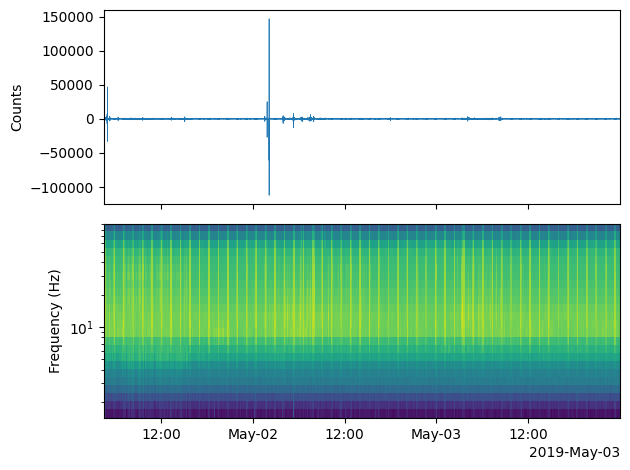

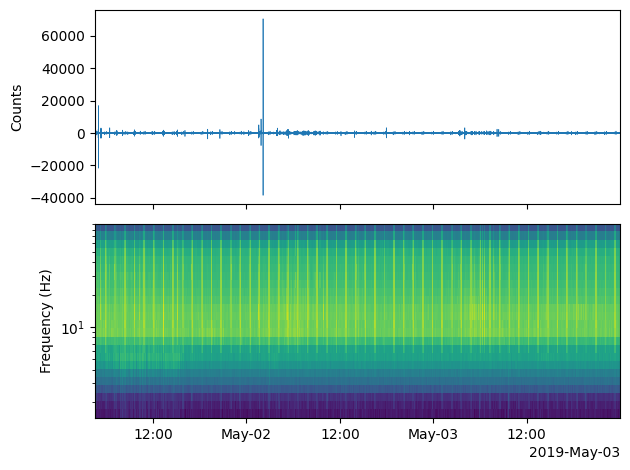

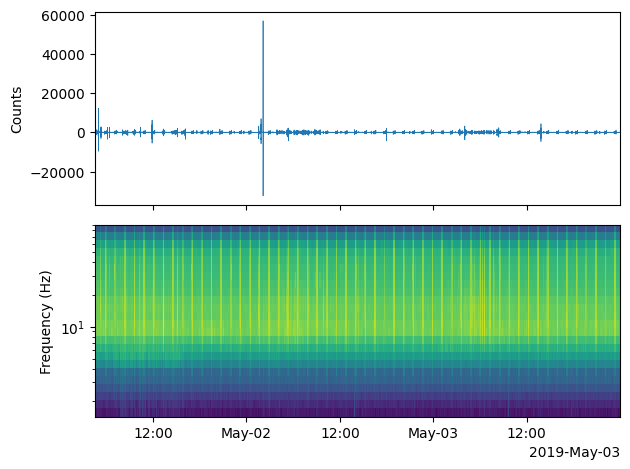

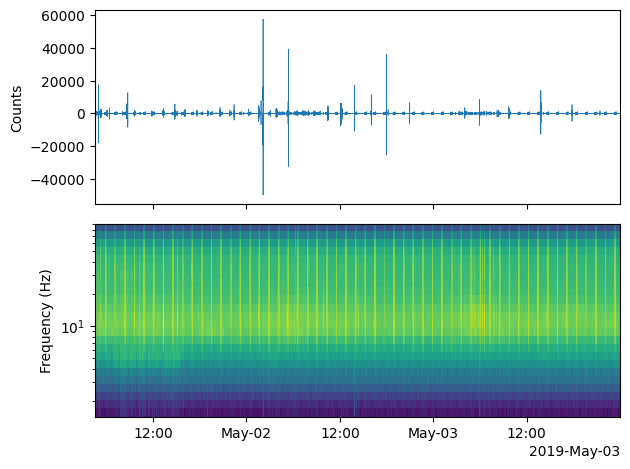

In [8]:
# Extract the first channel
center_frequencies = network.banks[0].centers

# Plot
for id, channel in enumerate(channels):
    trace = stream[id]
    data = np.log10(order_1)[:, id, :].squeeze().T
    
    # Create figure and axes
    fig, ax = plt.subplots(2, sharex=True)
    
    # Plot the waveform
    ax[0].plot(trace.times("matplotlib"), trace.data, rasterized=True, lw=0.5)
    
    # First-order scattering coefficients
    ax[1].pcolormesh(times, center_frequencies, data, rasterized=True)
    
    # Axes labels
    ax[1].set_yscale("log")
    ax[0].set_ylabel("Counts")
    ax[1].set_ylabel("Frequency (Hz)")
    
    # Show
    plt.tight_layout()
    #plt.savefig("seisscatt_test/scattering_coefficients0.png", orientation='landscape')

### Dimensionality reduction and clustering with UMAP: seismogram atlases

In [9]:
from sklearn.cluster import DBSCAN, KMeans
import umap.umap_ as umap

/fp/homes01/u01/ec-karinal/.conda/envs/saff/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


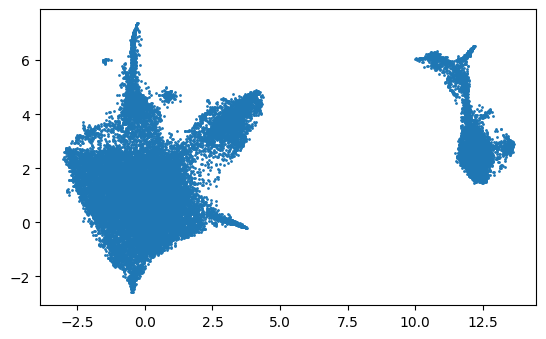

In [10]:
umap_model = umap.UMAP(n_components=2,random_state=42)
embedding = umap_model.fit_transform(scattering_coefficients)

# Visualize the UMAP results
fig, ax = plt.subplots()
ax.scatter(embedding[:,0],embedding[:,1],s=1)
ax.set_aspect('equal')

### Hierarchical clustering clustering with atlas

24297


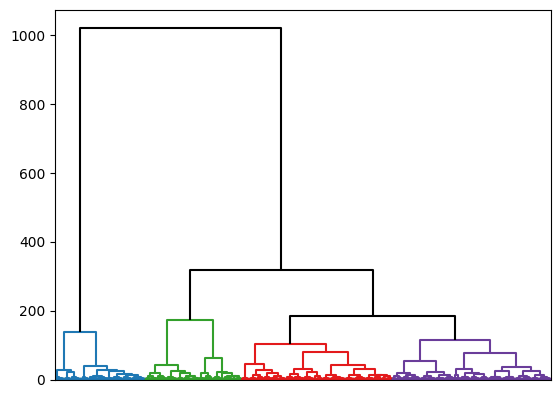

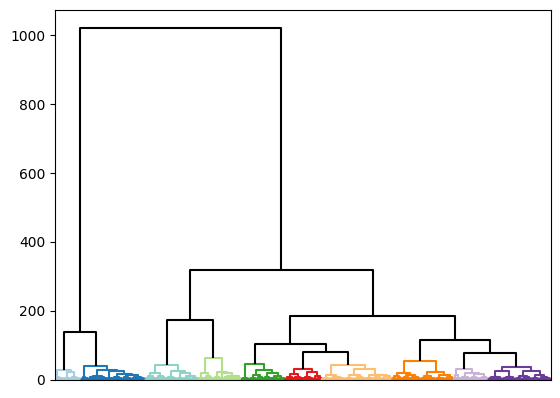

In [11]:
import fastcluster
from scipy.cluster.hierarchy import dendrogram, set_link_color_palette
from scipy.spatial.distance import pdist

N = len(embedding)
print(N)

def plot_with_labels(Z, num_clust, colorPalette):
    # plot the dendrogram
    set_link_color_palette(colorPalette)
    threshold = Z[-num_clust + 1, 2]
    dg = dendrogram(Z, no_labels = True, color_threshold = threshold, above_threshold_color='k')#, link_color_func=lambda k: classes[k])#, truncate_mode='lastp', p=10, show_leaf_counts=True)
    plt.show()
    return dg


D = pdist(embedding, metric = 'euclidean')
Z = fastcluster.linkage(D, method = 'ward')

dg0 = plot_with_labels(Z, 4, ['#1f78b4','#33a02c','#e31a1c','#6a3d9a'])
N_CLUSTERS=10
dg = plot_with_labels(Z, N_CLUSTERS, ['#a6cee3','#1f78b4','#8dd3c7','#b2df8a','#33a02c','#e31a1c','#fdbf6f','#ff7f00','#cab2d6','#6a3d9a','#ffff99'])

In [14]:
import pandas as pd
from collections import defaultdict
import string

dfg = pd.DataFrame({'leaves0':dg0['leaves'], 'Clade_color_list':dg0['leaves_color_list'],'leaves':dg['leaves'], 'leaves_color_list':dg['leaves_color_list']})

clade_labels = np.full_like(dfg['leaves_color_list'],'NN')
leaf_labels = np.full_like(dfg['leaves_color_list'],'NN')

for ii, clade_id in enumerate(np.unique(dg0['leaves_color_list'])):
    labelsClad = dfg['leaves_color_list'][dfg['Clade_color_list']==clade_id]
    clade_letter = string.ascii_uppercase[ii]
    
    for i, cluster_id in enumerate(np.unique(labelsClad)):
        leaf_letter = clade_letter+str(i) # A, B, C
        
        clade_labels[dfg['Clade_color_list']==clade_id] = clade_letter
        leaf_labels[dfg['leaves_color_list']==cluster_id] = leaf_letter

dfg['Clade_label'] = clade_labels
dfg['Leaf_label'] = leaf_labels
dfg

,leaves0,Clade_color_list,leaves,leaves_color_list,Clade_label,Leaf_label
0,14,#1f78b4,14,#a6cee3,A,A1
1,992,#1f78b4,992,#a6cee3,A,A1
2,9442,#1f78b4,9442,#a6cee3,A,A1
3,9000,#1f78b4,9000,#a6cee3,A,A1
4,4480,#1f78b4,4480,#a6cee3,A,A1
...,...,...,...,...,...,...
24292,6103,#6a3d9a,6103,#6a3d9a,C,C0
24293,19567,#6a3d9a,19567,#6a3d9a,C,C0
24294,15891,#6a3d9a,15891,#6a3d9a,C,C0
24295,10136,#6a3d9a,10136,#6a3d9a,C,C0


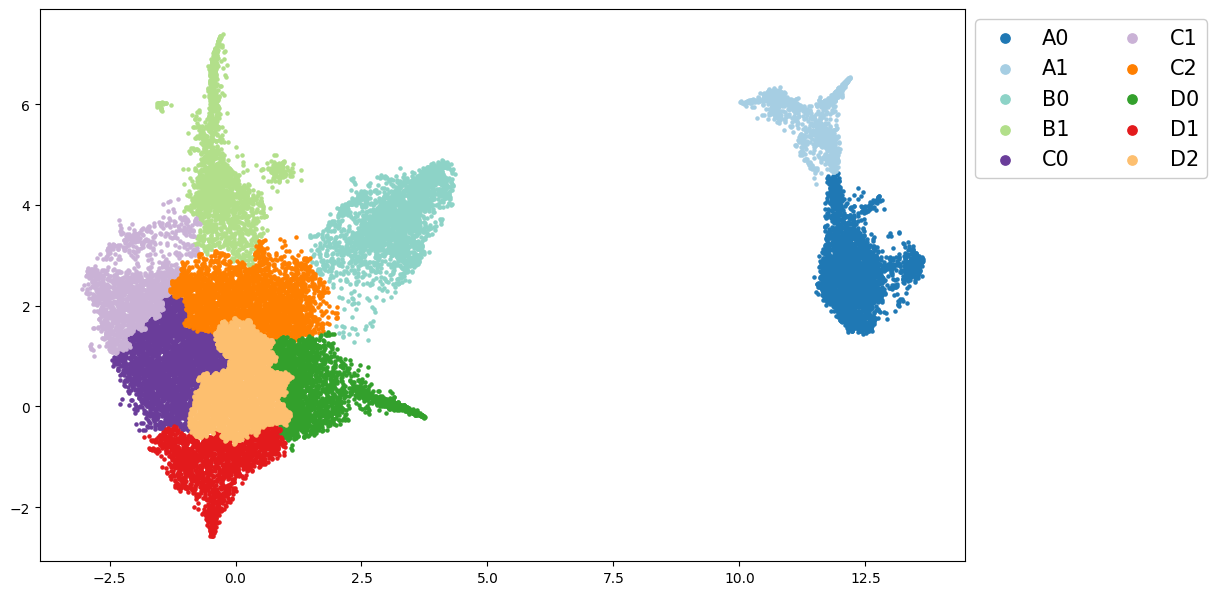

In [15]:
labelsL = dfg.Leaf_label.values
leavs = dfg.leaves.values
leaves_color = dfg.leaves_color_list.values

# show clustering results in the atlas
fig, ax = plt.subplots(figsize=(12, 7))
for i, label in enumerate(np.unique(labelsL)):
    
    where = label == labelsL
    col = leaves_color[where][0]
    ax.scatter(embedding[leavs[where],0],embedding[leavs[where],1],s=5, label=label, color=col)
ax.set_aspect('equal')
plt.legend(fontsize = 15, loc="upper left", framealpha=1, bbox_to_anchor=(1, 1), ncols=2, markerscale=3)
#plt.show()
plt.tight_layout()
#plt.savefig("seisscatt_test/UMAP_"+str(N_CLUSTERS)+".png", orientation='landscape')

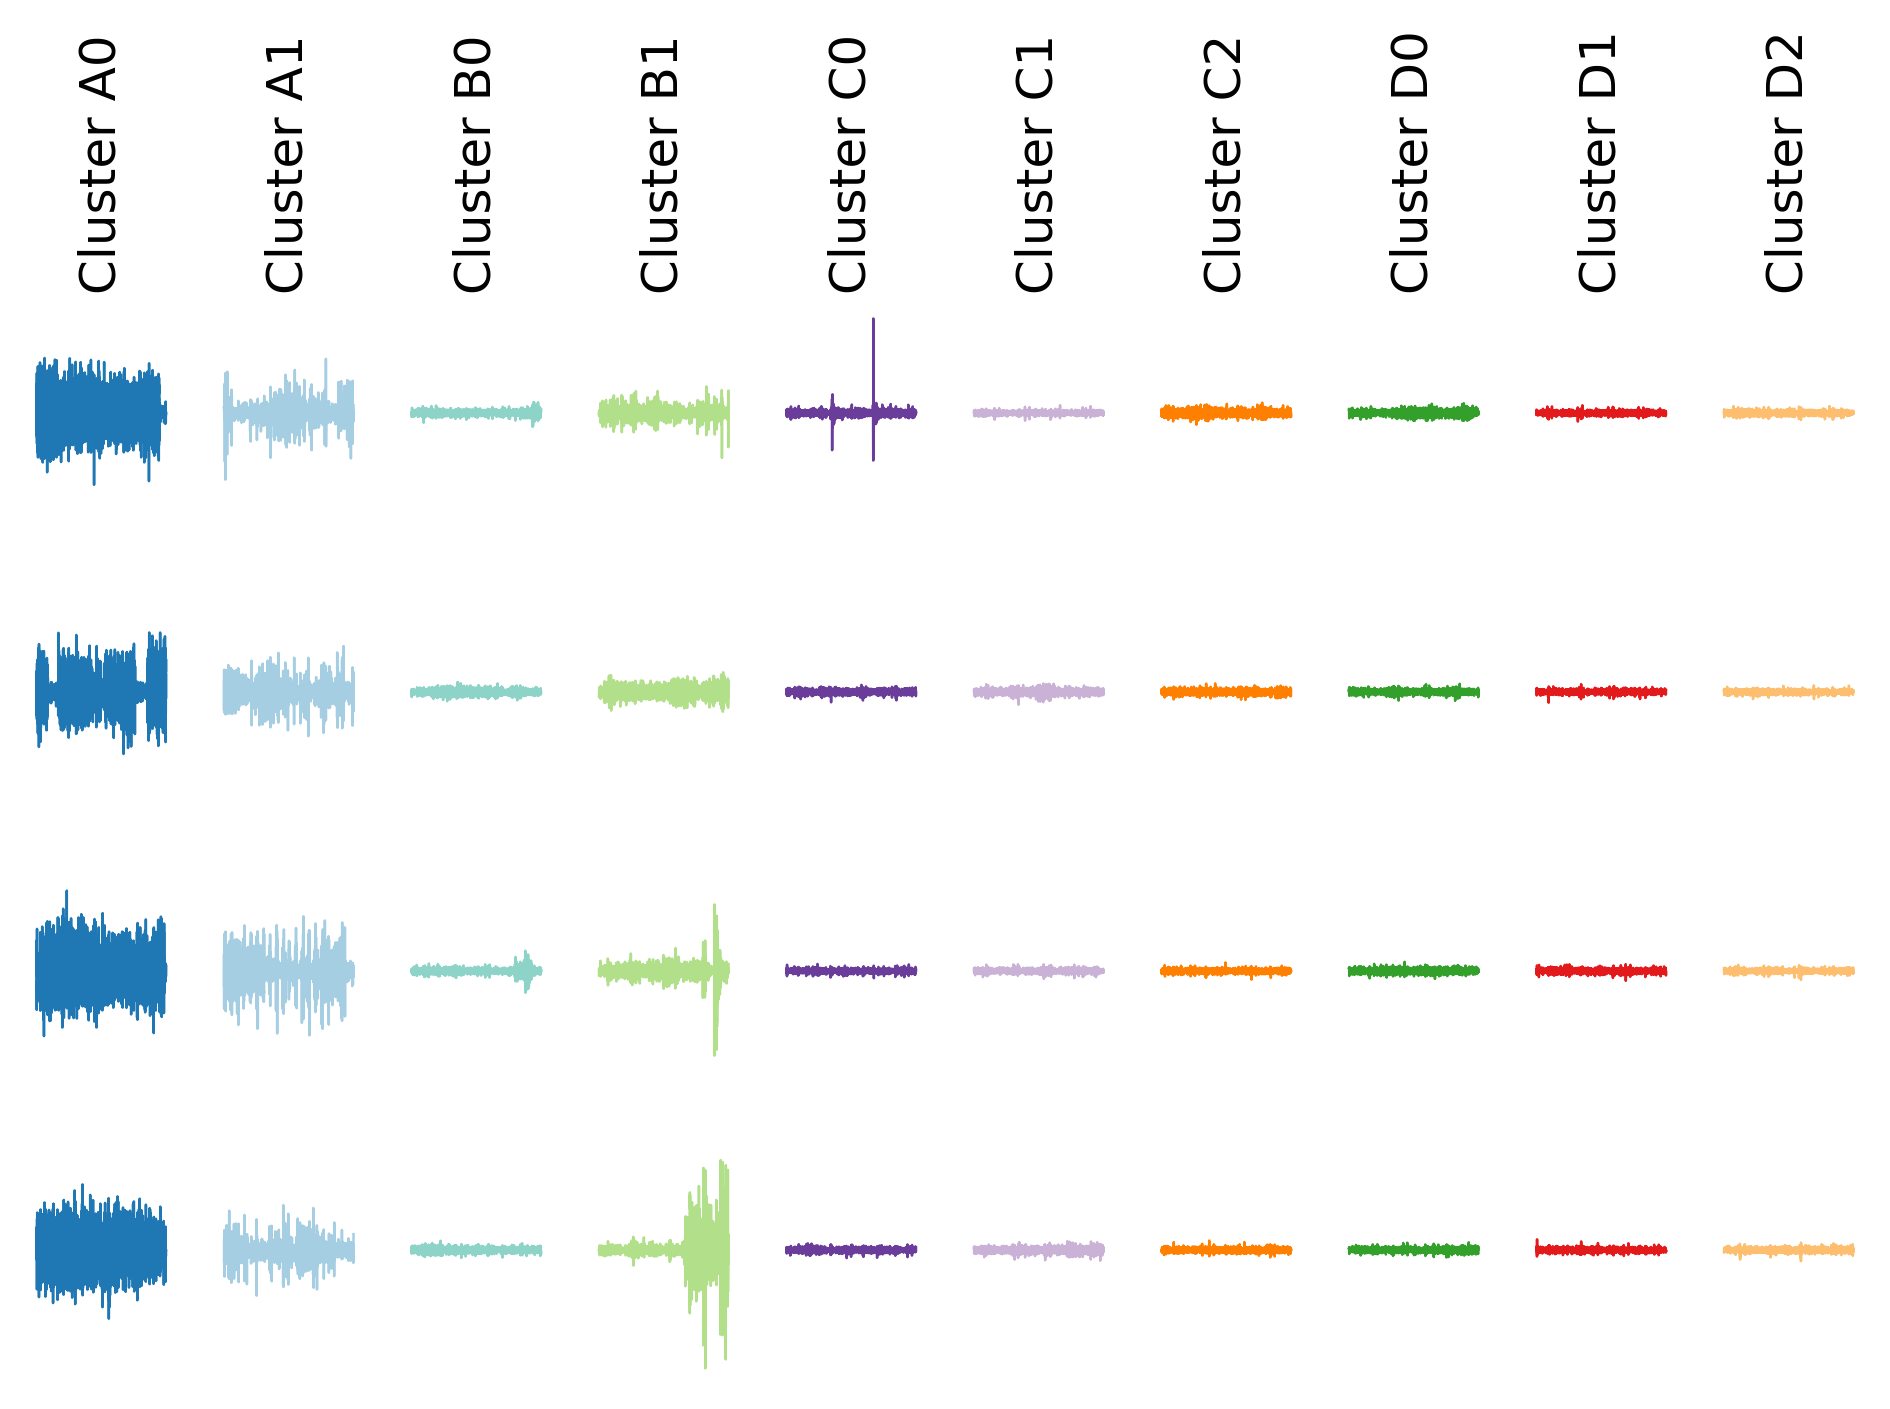

In [17]:
N_WAVEFORMS = 4

waveform_duration = network.bins / network.sampling_rate

clustersU = np.unique(labelsL)
# Extract waveforms
waveforms = list()
for cluster in clustersU:
    where = cluster == labelsL
    
    # Calculate the distance of each sample to the cluster mean
    mean = np.mean(embedding[leavs[where]], axis=0)
    distance = np.linalg.norm(embedding[leavs[where]] - mean, axis=1)
    closest = times[leavs[where]][distance.argsort()[:5]]

    # Collect closest waveforms in a list
    traces = list()
    for time in closest[:N_WAVEFORMS]:
        time = UTCDateTime(time)
        trace = stream.slice(time, time + waveform_duration)[0].copy()
        traces.append(trace)
    waveforms.append(traces)

# Plot the results
fig, ax = plt.subplots(N_WAVEFORMS, N_CLUSTERS, sharex=True, sharey=True, dpi=300)

# Plot each cluster as a separate line
for i, traces in enumerate(waveforms):
    ax[0, i].set_title(f"Cluster {clustersU[i]}", rotation="vertical")
    where = clustersU[i] == labelsL
    col = leaves_color[where][0]
    for j, trace in enumerate(traces):
        ax[j, i].plot(trace.times(), trace.data, rasterized=True, lw=0.6, color=col)
        ax[j, i].set_axis_off()

# Show
#plt.show()
plt.tight_layout()
#plt.savefig("seisscatt_test/hclusters_"+str(N_CLUSTERS)+"_UMAP.png", orientation='landscape')

In [41]:
# Make dataframe with waveform and cluster 
N_WAVEFORMS = 4

win_start = []
win_end = []
win_clust = []


waveform_duration = network.bins / network.sampling_rate
clustersU = np.unique(labelsL)
# Extract waveforms
waveforms = list()
for cluster in clustersU:
    where = cluster == labelsL
    
    # Calculate the distance of each sample to the cluster mean
    mean = np.mean(embedding[leavs[where]], axis=0)
    distance = np.linalg.norm(embedding[leavs[where]] - mean, axis=1)
    closest = times[leavs[where]][distance.argsort()]

    # Collect closest waveforms in a list
    traces = list()
    for time in closest:
        time = UTCDateTime(time)
        win_start.append(time)
        win_end.append(time + waveform_duration)
        win_clust.append(cluster)

dfwc = pd.DataFrame({'window_start':win_start,'window_end':win_end,'cluster':win_clust})
dfwc.to_csv('window_clusters.csv')
dfwc

24297

24297

4 Trace(s) in Stream:
7F.A00.03.GDH | 2019-05-01T04:30:17.998000Z - 2019-05-04T00:00:03.563000Z | 200.0 Hz, 48597114 samples
7F.A00.04.GDH | 2019-05-01T04:30:17.998000Z - 2019-05-04T00:00:00.408000Z | 200.0 Hz, 48596483 samples
7F.A00.05.GDH | 2019-05-01T04:30:17.998000Z - 2019-05-04T00:00:02.728000Z | 200.0 Hz, 48596947 samples
7F.A00.06.GDH | 2019-05-01T04:30:17.998000Z - 2019-05-04T00:00:02.753000Z | 200.0 Hz, 48596952 samples

##  Do next
 1) Check the effects of pooling method
 2) Assign a cluster to each waveform segment (?)
 3) Compare cluster to template match
 4) Make cumplots for templates
 5) Try to combine the scattering networks and make umap
 6) Move to upgraded git reps
 7) Make a few figures and slides for John when he goes to texas (?)